# Import libraries

In [1]:
!pip install split-folders
!pip install tqdm
!pip install scikit-image
!pip install opencv-python


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, shutil
import splitfolders
import random
import numpy as np
import pandas as pd
import itertools
from tqdm import tqdm, tqdm_notebook
import cv2
from scipy import stats
from sklearn.metrics import confusion_matrix, roc_curve,auc, classification_report, precision_score, recall_score
from sklearn.linear_model import LinearRegression

import skimage
import skimage.segmentation
import copy

# Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg


import tensorflow as tf
print(tf.__version__)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Flatten, Dense, MaxPooling2D, Conv2D, Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.imagenet_utils import decode_predictions

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/resour

2.20.0


# Load data and split the data into training, validation and testing datasets

In [3]:
original_dataset = r'C:\Users\HP\Downloads\malaria-detection-combined-main\cell_images'
original_dataset_parasitized = os.path.join(original_dataset, 'Parasitized')
original_dataset_uninfected = os.path.join(original_dataset, 'Uninfected')

Copying images into training, validation and test directories

In [4]:
# Create a base dir
if not os.path.isdir('healthy_and_infected'):
                base_dir = r'C:\Users\HP\Downloads\malaria-detection-combined-main\healthy_and_infected'
                os.makedirs(base_dir,exist_ok=True)

In [5]:
# Make train, valid and test directories
#train
if not os.path.isdir('healthy_and_infected/train'):
    train_dir = os.path.join(base_dir, 'train')
    os.makedirs(train_dir,exist_ok=True)
#valid
if not os.path.isdir('healthy_and_infected/valid'):
    valid_dir = os.path.join(base_dir, 'valid')
    os.makedirs(valid_dir,exist_ok=True)
#test
if not os.path.isdir('healthy_and_infected/test'):
    test_dir = os.path.join(base_dir, 'test')
    os.makedirs(test_dir,exist_ok=True)

In [6]:
# Make directories for infected images in each of the train, valid and test directories
if not os.path.isdir('healthy_and_infected/train/infected'):
    infected_trn_dir = os.path.join(train_dir, 'infected')
    os.makedirs(infected_trn_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/valid/infected'):
    infected_valid_dir = os.path.join(valid_dir, 'infected')
    os.makedirs(infected_valid_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/test/infected'):
    infected_test_dir = os.path.join(test_dir, 'infected')
    os.makedirs(infected_test_dir,exist_ok=True)

In [7]:
# Make directories for healthy images in each of the train, valid and test directories
if not os.path.isdir('healthy_and_infected/train/healthy'):
    healthy_trn_dir = os.path.join(train_dir, 'healthy')
    os.makedirs(healthy_trn_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/valid/healthy'):
    healthy_valid_dir = os.path.join(valid_dir, 'healthy')
    os.makedirs(healthy_valid_dir,exist_ok=True)

if not os.path.isdir('healthy_and_infected/test/healthy'):
    healthy_test_dir = os.path.join(test_dir, 'healthy')
    os.makedirs(healthy_test_dir,exist_ok=True)

In [8]:
# Copies the first 10981 infected images to the infected_train_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) if f.endswith('.png')][:10980]
for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_trn_dir, fname)
    shutil.copyfile(src,dst)

In [9]:
# Copies the 1400 infected images (10981, 12382) to the infected_valid_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) if f.endswith('.png')][10981:12382]
for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_valid_dir, fname)
    shutil.copyfile(src,dst)

In [10]:
### Copy another 1400 infected images () to the infected_test_dir
fnames = [f for f in os.listdir(original_dataset_parasitized) if f.endswith('.png')][12382:13780]
for fname in fnames:
    src = os.path.join(original_dataset_parasitized, fname)
    dst = os.path.join(infected_test_dir, fname)
    shutil.copyfile(src,dst)

In [11]:
# Copies the first 10981 uninfected images to the healthy_train_dir
fnames = [f for f in os.listdir(original_dataset_uninfected) if f.endswith('.png')][:10981]
for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_trn_dir, fname)
    shutil.copyfile(src,dst)

In [12]:
# Copies the 1400 uninfected images (10981, 12382) to the healthy_valid_dir
fnames = [f for f in os.listdir(original_dataset_uninfected) if f.endswith('.png')][10981:12382]
for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_valid_dir, fname)
    shutil.copyfile(src,dst)

In [13]:
### Copy another 1400 uninfected images () to the healthy_test_dir
fnames = [f for f in os.listdir(original_dataset_uninfected) if f.endswith('.png')][12382:13780]
for fname in fnames:
    src = os.path.join(original_dataset_uninfected, fname)
    dst = os.path.join(healthy_test_dir, fname)
    shutil.copyfile(src,dst)

In [14]:
print("{} Infected training images".format(len(os.listdir(infected_trn_dir))))
print("{} Uninfected training images".format(len(os.listdir(healthy_trn_dir))))
print(" {} Infected valid images".format(len(os.listdir(infected_valid_dir))))
print(" {} Uninfected valid images".format(len(os.listdir(healthy_valid_dir))))
print(" {} Infected testing images".format(len(os.listdir(infected_test_dir))))
print(" {} Uninfected testing images".format(len(os.listdir(healthy_test_dir))))

10980 Infected training images
10981 Uninfected training images
 1401 Infected valid images
 1401 Uninfected valid images
 1397 Infected testing images
 1397 Uninfected testing images


# Exploratory Data Analysis

In [17]:
# Train
infected_trn_fpaths = [os.path.join(infected_trn_dir, fpath) for fpath in os.listdir(infected_trn_dir)]
healthy_trn_fpaths = [os.path.join(healthy_trn_dir, fpath) for fpath in os.listdir(healthy_trn_dir)]

# Valid
infected_valid_fpaths = [os.path.join(infected_valid_dir, fpath) for fpath in os.listdir(infected_valid_dir)]
healthy_valid_fpaths = [os.path.join(healthy_valid_dir, fpath) for fpath in os.listdir(healthy_valid_dir)]

# Test
infected_test_fpaths = [os.path.join(infected_test_dir, fpath) for fpath in os.listdir(infected_test_dir)]
healthy_test_fpaths = [os.path.join(healthy_test_dir, fpath) for fpath in os.listdir(healthy_test_dir)]


In [18]:
def get_img_shape(idx, img, total_num_images):
    
    if idx%2000 ==0 or idx == (total_num_images-1):
        print("working on img {}".format(idx))
    return cv2.imread(img).shape

data_inp = [(idx, img, len(infected_trn_fpaths + healthy_trn_fpaths)) for idx, img in enumerate(infected_trn_fpaths + healthy_trn_fpaths)]

train_img_dims_map = list(map(get_img_shape, [input[0] for input in data_inp],
    [input[1] for input in data_inp],
    [input[2] for input in data_inp]))

working on img 0
working on img 2000
working on img 4000
working on img 6000
working on img 8000
working on img 10000
working on img 12000
working on img 14000
working on img 16000
working on img 18000
working on img 20000
working on img 21960


In [19]:
print('Min Dimensions:           {}'.format(np.min(train_img_dims_map, axis=0)))
print('Avg Dimensions:           {}'.format(np.mean(train_img_dims_map, axis=0)))
print('Median Dimensions:        {}'.format(np.median(train_img_dims_map, axis=0)))
print('Most Frequent Dimensions: {}'.format(stats.mode(train_img_dims_map, axis=0)[0]))
print('Max Dimensions:           {}'.format(np.max(train_img_dims_map, axis=0)))

Min Dimensions:           [40 46  3]
Avg Dimensions:           [132.05714676 131.56659533   3.        ]
Median Dimensions:        [130. 130.   3.]
Most Frequent Dimensions: [130 130   3]
Max Dimensions:           [346 265   3]


In [20]:
infected_trn_samples = random.sample(infected_trn_fpaths, 5)
healthy_trn_samples = random.sample(healthy_trn_fpaths, 5)

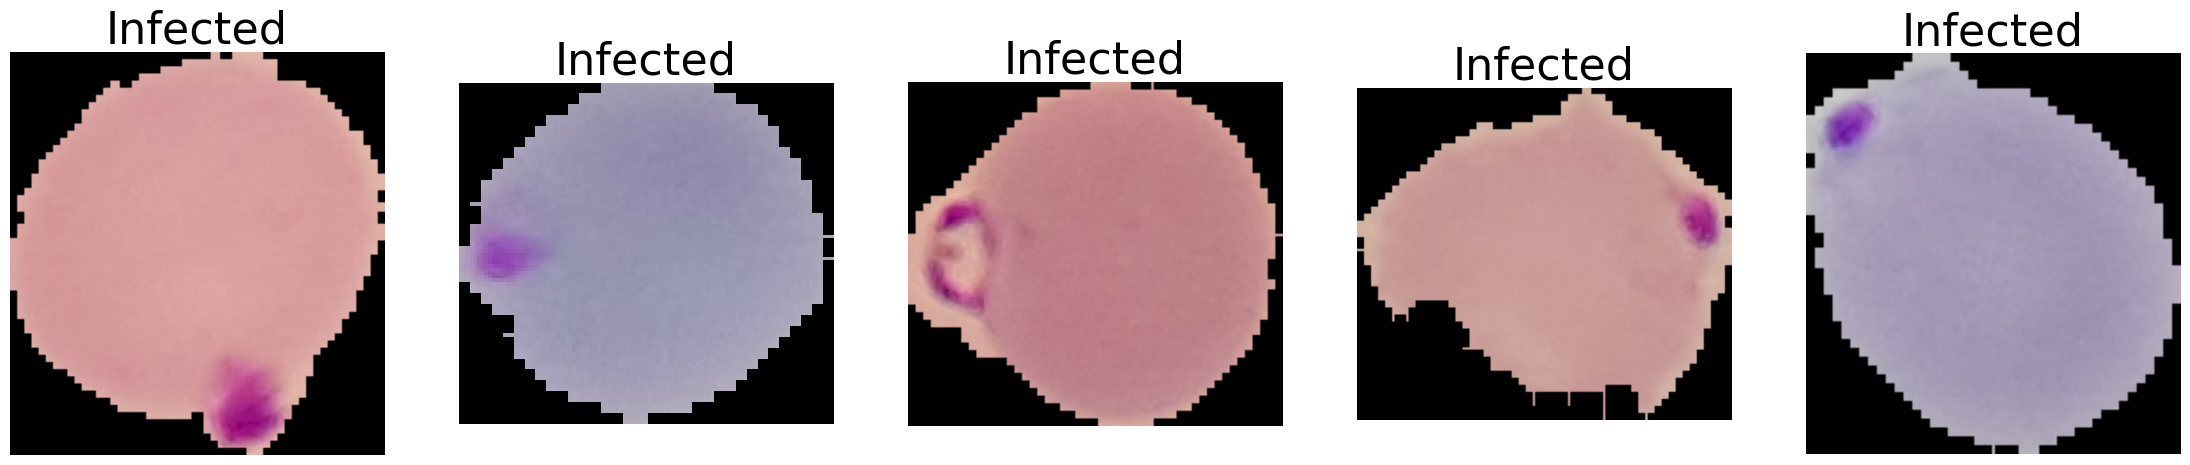

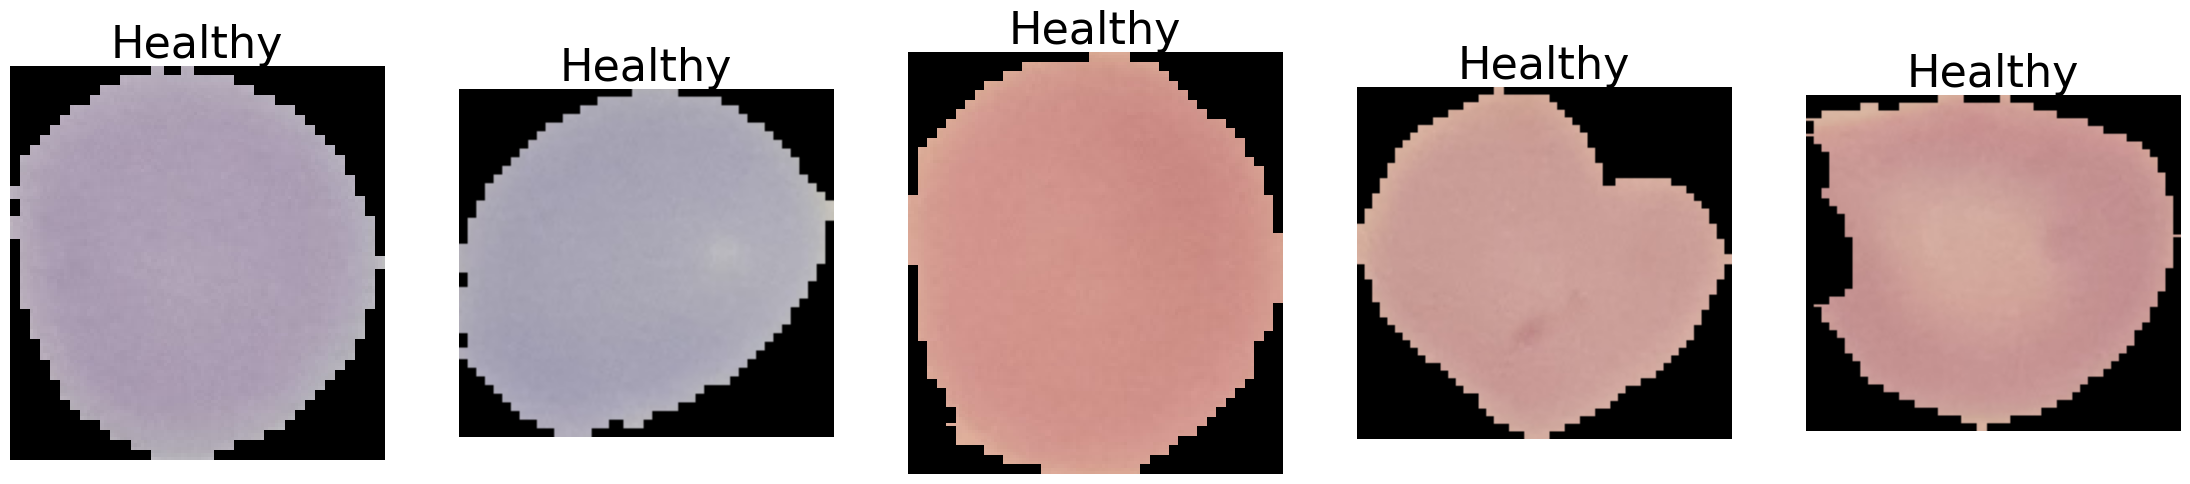

In [21]:
fig =plt.figure(figsize=(28,14))
columns=5
rows=1
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    plt.imshow(mpimg.imread(infected_trn_samples[i-1]))
    plt.axis('off')
    plt.title('Infected', fontsize=32)
plt.show()


fig =plt.figure(figsize=(28,14))
columns=5
rows=1
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    plt.imshow(mpimg.imread(healthy_trn_samples[i-1]))
    plt.axis('off')
    plt.title('Healthy', fontsize=32)
plt.show()


# Data Augumentation and resizing images

In [22]:
train_datagen = ImageDataGenerator(rescale=1./255.,
                                   horizontal_flip=True,
                                   vertical_flip=0.4,
                                   rotation_range=30,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   brightness_range=[0.8,1.2],
                                   fill_mode='nearest')
valid_datagen = ImageDataGenerator(rescale=1.0/255.)
test_datagen = ImageDataGenerator(rescale=1.0/255.)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=32,
                                                    target_size=(128,128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

valid_generator = valid_datagen.flow_from_directory(valid_dir,
                                                    batch_size=32,
                                                    target_size=(128, 128),
                                                    class_mode='categorical',
                                                    shuffle=True,
                                                    seed=42,
                                                    color_mode='rgb')

class_labels = train_generator.class_indices
class_names = {value:key for (key, value) in class_labels.items()}

Found 21961 images belonging to 2 classes.
Found 2802 images belonging to 2 classes.


In [23]:
class_labels, class_names

({'healthy': 0, 'infected': 1}, {0: 'healthy', 1: 'infected'})

# Transfer Learning - VGG19 CNN architecture

In [24]:
# Instantiate VGG19 model with weights from Imagenet without the calssifier at the top
base_model = VGG19(input_shape = (128,128,3),
                   include_top = False, 
                   weights = 'imagenet')
# Freeze the ConvNet to avoid weight updates
for layer in base_model.layers:
    layer.trainable=False
    
x = base_model.output
flat=Flatten()(x)

# Add a classifier -  a fully connected dense layers
class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

# Bake a model
model_01 = Model(base_model.inputs, output)
model_01.summary()

# Call backs
filepath = 'best_model.h5'
es = EarlyStopping(monitor='val_loss', verbose=1, mode='min', patience=4)
cp = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True,
                     save_weights_only=False, mode='auto', save_freq='epoch')
lrr = ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.5,min_lr=0.0001)

# Define an optimizer
sgd = SGD(learning_rate=.0001, decay=1e-6, momentum=0.9, nesterov=True)

# Compile the model
model_01.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=["accuracy"])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4608)           │    37,753,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 43,065,218 (164.28 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [25]:
# Fit the model on the training set and train for 10 epochs
history_01 = model_01.fit(train_generator,
                                 steps_per_epoch=50,
                                 epochs=5,
                                 callbacks = [es, cp, lrr],
                                 validation_data = valid_generator)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4987 - loss: 0.7235
Epoch 1: val_loss improved from None to 0.67768, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 291s 6s/step - accuracy: 0.5400 - loss: 0.6960 - val_accuracy: 0.5007 - val_loss: 0.6777 - learning_rate: 1.0000e-04
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6289 - loss: 0.6459
Epoch 2: val_loss improved from 0.67768 to 0.57749, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.6531 - loss: 0.6268 - val_accuracy: 0.7113 - val_loss: 0.5775 - learning_rate: 1.0000e-04
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7134 - loss: 0.5677
Epoch 3: val_loss improved from 0.57749 to 0.53690, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 252s 5s/step - accuracy: 0.7306 - loss: 0.5615 - val_accuracy: 0.7566 - val_loss: 0.5369 - learning_rate: 1.0000e-04
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7341 - loss: 0.5440
Epoch 4: val_loss improved from 0.53690 to 0.51150, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 253s 5s/step - accuracy: 0.7319 - loss: 0.5431 - val_accuracy: 0.7791 - val_loss: 0.5115 - learning_rate: 1.0000e-04
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7630 - loss: 0.5125
Epoch 5: val_loss improved from 0.51150 to 0.51065, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 248s 5s/step - accuracy: 0.7569 - loss: 0.5190 - val_accuracy: 0.7580 - val_loss: 0.5106 - learning_rate: 1.0000e-04


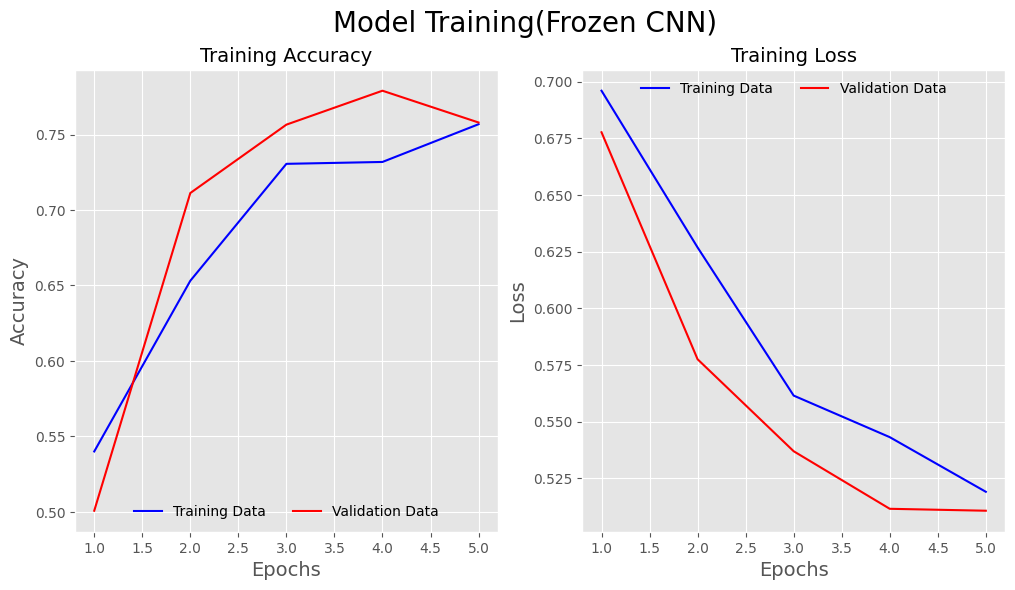

In [26]:
# Plot performance
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
fig.suptitle("Model Training(Frozen CNN)", fontsize=20)
max_epoch = len(history_01.history['accuracy'])+1
epochs_list = list(range(1, max_epoch))

ax1.plot(epochs_list, history_01.history['accuracy'], color='b', linestyle='-', label='Training Data')
ax1.plot(epochs_list, history_01.history['val_accuracy'], color='r', linestyle='-', label='Validation Data')
ax1.set_title('Training Accuracy', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=14)
ax1.legend(frameon=False, loc='lower center', ncol=2)

ax2.plot(epochs_list, history_01.history['loss'], color='b', linestyle='-', label='Training Data')
ax2.plot(epochs_list, history_01.history['val_loss'], color='r', linestyle='-', label='Validation Data')
ax2.set_title('Training Loss', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=14)
ax2.set_ylabel('Loss', fontsize=14)
ax2.legend(frameon=False, loc='upper center', ncol=2)

In [27]:
# save model
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_01.save_weights(filepath="model_weights/vgg19_model_01.weights.h5", overwrite=True)

In [28]:
# Resize test images similar to the train data
test_generator = test_datagen.flow_from_directory(test_dir,
                                                  batch_size=1,
                                                  target_size=(128, 128),
                                                  class_mode='categorical',
                                                  shuffle=False,
                                                  seed=42,
                                                  color_mode='rgb')

Found 2794 images belonging to 2 classes.


In [29]:
# Load the saved model
model_01.load_weights('model_weights/vgg19_model_01.weights.h5')
# Evaluate the model on the hold out validation and test datasets

# Evaluate the model on batches of validation and testing data
vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

print('Validation loss:     {0:.2f}'.format(vgg_val_eval_01[0]))
print('Validation accuracy: {0:.2f}'.format(vgg_val_eval_01[1]))
print('Test loss:           {0:.2f}'.format(vgg_test_eval_01[0]))
print('Test accuracy:       {0:.2f}'.format(vgg_test_eval_01[1]))

88/88 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.7580 - loss: 0.5106
2794/2794 ━━━━━━━━━━━━━━━━━━━━ 516s 185ms/step - accuracy: 0.7230 - loss: 0.5059
Validation loss:     0.51
Validation accuracy: 0.76
Test loss:           0.51
Test accuracy:       0.72


In [30]:
filenames = test_generator.filenames
nb_samples = len(filenames)
vgg_predictions_01 = model_01.predict(test_generator,
                                                steps = nb_samples,
                                                verbose=1)
vgg_pred_labels_01= np.argmax(vgg_predictions_01, axis=1)


2794/2794 ━━━━━━━━━━━━━━━━━━━━ 521s 186ms/step


In [31]:
# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_01, 
                            target_names=['healthy', 'infected']))
vgg_conf_mat_01 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_01), 
                        index=['healthy', 'infected'], 
                        columns=['healthy', 'infected'])


              precision    recall  f1-score   support

     healthy       0.96      0.46      0.63      1397
    infected       0.65      0.98      0.78      1397

    accuracy                           0.72      2794
   macro avg       0.81      0.72      0.70      2794
weighted avg       0.81      0.72      0.70      2794



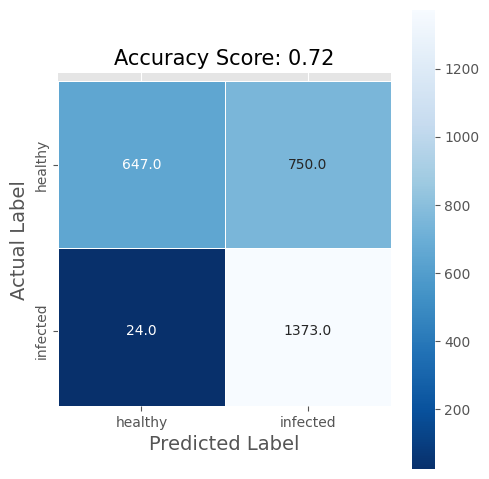

In [32]:
fig, ax = plt.subplots(figsize=(5,5))
#plt.figure(figsize=(9,9))
sns.heatmap(vgg_conf_mat_01, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Blues_r')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title="Accuracy Score: {0:.2f}".format(vgg_test_eval_01[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_01)-0.05, -0.05)
plt.tight_layout()

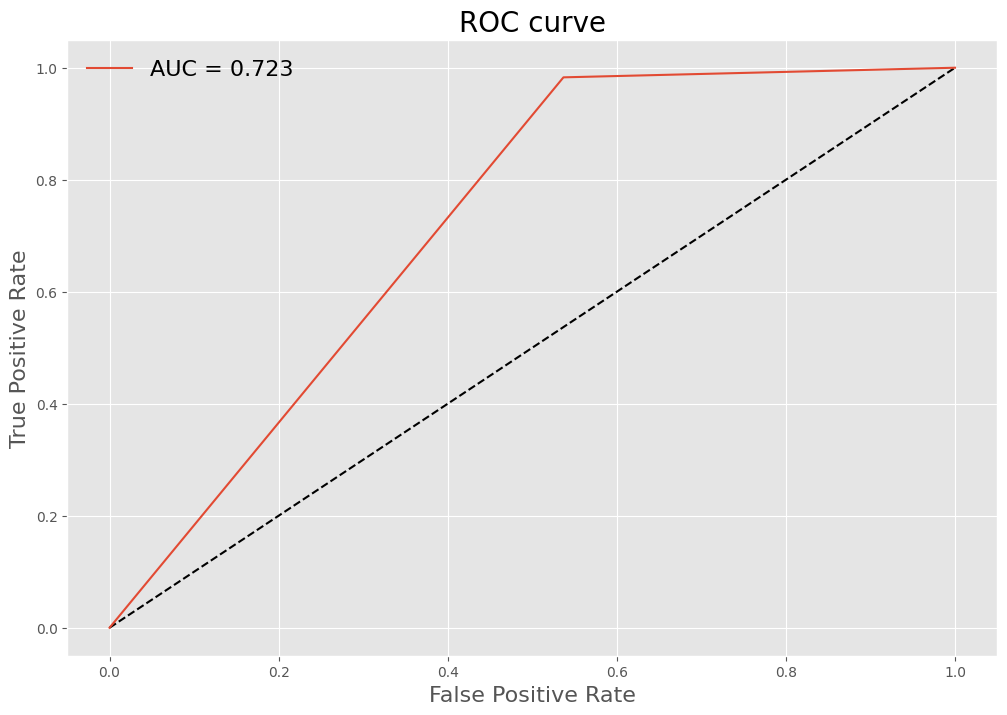

In [33]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_01)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, label='AUC = {:.3f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)

# Incremental Unfreezing and fine-tuning

In [ ]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))
base_model_layer_names = [layer.name for layer in base_model.layers]
base_model_layer_names

x = base_model.output

flat=Flatten()(x)

class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)

model_02 = Model(base_model.inputs, output)
model_02.load_weights('model_weights/vgg19_model_01.weights.h5')

set_trainable = False
for layer in base_model.layers:
    if layer.name in ['block5_conv4', 'block5_conv3']:
        set_trainable=True
    if set_trainable:
        layer.trainable=True
    else:
        layer.trainable=False

print(model_02.summary())

In [ ]:
sgd = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
#model_02 = Model(base_model.inputs, output)
model_02.compile(optimizer=sgd,
                loss='categorical_crossentropy',
                metrics=['accuracy'])

In [ ]:
history_02 = model_02.fit(train_generator,
                                 steps_per_epoch=10,
                                 epochs=5,
                                 callbacks = [es, cp, lrr],
                                 validation_data = valid_generator)

In [ ]:
# save model
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_02.save_weights(filepath='model_weights/vgg19_model_02.weights.h5', overwrite=True)

In [ ]:
## Evaluating the model

In [ ]:
# Load the saved model
model_02.load_weights('model_weights/vgg19_model_02.weights.h5')
# Evaluate the model on the hold out validation and test datasets

vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print('Validation loss:     {}'.format(vgg_val_eval_02[0]))
print('Validation accuracy: {}'.format(vgg_val_eval_02[1]))
print('Test loss:           {}'.format(vgg_test_eval_02[0]))
print('Test accuracy:       {}'.format(vgg_test_eval_02[1]))


filenames = test_generator.filenames
nb_samples = len(filenames)
vgg_predictions_02 = model_02.predict(test_generator,
                                                steps = nb_samples,
                                                verbose=1)
vgg_pred_labels_02 = np.argmax(vgg_predictions_02, axis=1)


# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_02, 
                            target_names=['healthy', 'infected']))
vgg_conf_mat_02 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_02), 
                        index=['healthy', 'infected'], 
                        columns=['healthy', 'infected'])


fig, ax = plt.subplots(figsize=(5,5))

sns.heatmap(vgg_conf_mat_02, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Blues_r')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title="Accuracy Score: {0:.2f}".format(vgg_test_eval_02[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_02)-0.05, -0.05)
plt.tight_layout()

In [ ]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_02)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, label='AUC = {:.3f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)

# Unfreezing and Fine-tuning the entire network

In [34]:
# Build the network
base_model = VGG19(include_top=False, input_shape=(128,128,3))
x = base_model.output
flat=Flatten()(x)
class_1 = Dense(4608, activation='relu')(flat)
drop_out = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation='relu')(drop_out)
output = Dense(2, activation='softmax')(class_2)
model_03 = Model(base_model.inputs, output)

# Load weights
model_03.load_weights('model_weights/vgg19_model_02.weights.h5')

sgd = SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)
# Compile the model
model_03.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

In [35]:
history_03 = model_03.fit(train_generator,
                                    steps_per_epoch=100,
                                    epochs=10,
                                    callbacks = [es, cp, lrr],
                                    validation_data = valid_generator)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8748 - loss: 0.3113
Epoch 1: val_loss improved from 0.51065 to 0.15665, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 798s 8s/step - accuracy: 0.8925 - loss: 0.2826 - val_accuracy: 0.9443 - val_loss: 0.1566 - learning_rate: 1.0000e-04
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9156 - loss: 0.2396 
Epoch 2: val_loss improved from 0.15665 to 0.13051, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1641s 17s/step - accuracy: 0.9203 - loss: 0.2313 - val_accuracy: 0.9640 - val_loss: 0.1305 - learning_rate: 1.0000e-04
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9122 - loss: 0.2361
Epoch 3: val_loss improved from 0.13051 to 0.12608, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 836s 8s/step - accuracy: 0.9181 - loss: 0.2256 - val_accuracy: 0.9647 - val_loss: 0.1261 - learning_rate: 1.0000e-04
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9295 - loss: 0.1991
Epoch 4: val_loss improved from 0.12608 to 0.11874, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1151s 12s/step - accuracy: 0.9320 - loss: 0.1959 - val_accuracy: 0.9640 - val_loss: 0.1187 - learning_rate: 1.0000e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9331 - loss: 0.1924
Epoch 5: val_loss did not improve from 0.11874
100/100 ━━━━━━━━━━━━━━━━━━━━ 980s 10s/step - accuracy: 0.9319 - loss: 0.1973 - val_accuracy: 0.9679 - val_loss: 0.1338 - learning_rate: 1.0000e-04
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9299 - loss: 0.1945
Epoch 6: val_loss improved from 0.11874 to 0.11811, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 967s 10s/step - accuracy: 0.9325 - loss: 0.1911 - val_accuracy: 0.9690 - val_loss: 0.1181 - learning_rate: 1.0000e-04
Epoch 7/10
 87/100 ━━━━━━━━━━━━━━━━━━━━ 1:44 8s/step - accuracy: 0.9363 - loss: 0.1765

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 7: val_loss did not improve from 0.11811
100/100 ━━━━━━━━━━━━━━━━━━━━ 906s 9s/step - accuracy: 0.9332 - loss: 0.1822 - val_accuracy: 0.9504 - val_loss: 0.1899 - learning_rate: 1.0000e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9300 - loss: 0.1865
Epoch 8: val_loss improved from 0.11811 to 0.11230, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4344s 44s/step - accuracy: 0.9287 - loss: 0.1851 - val_accuracy: 0.9675 - val_loss: 0.1123 - learning_rate: 1.0000e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 37s/step - accuracy: 0.9350 - loss: 0.1867 
Epoch 9: val_loss did not improve from 0.11230
100/100 ━━━━━━━━━━━━━━━━━━━━ 4289s 41s/step - accuracy: 0.9281 - loss: 0.2018 - val_accuracy: 0.9657 - val_loss: 0.1297 - learning_rate: 1.0000e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9322 - loss: 0.1985 
Epoch 10: val_loss did not improve from 0.11230
100/100 ━━━━━━━━━━━━━━━━━━━━ 1662s 17s/step - accuracy: 0.9334 - loss: 0.1854 - val_accuracy: 0.9686 - val_loss: 0.1139 - learning_rate: 1.0000e-04


In [36]:
# save model
if not os.path.isdir('model_weights/'):
    os.mkdir('model_weights/')
model_03.save_weights(filepath='model_weights/vgg_unfrozen.weights.h5', overwrite=True)

## Evaluating the model

88/88 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9686 - loss: 0.1139
2794/2794 ━━━━━━━━━━━━━━━━━━━━ 416s 149ms/step - accuracy: 0.9538 - loss: 0.1481
Validation loss     :0.11
Validation accuracy :0.97
Test loss           :0.15
Test accuracy       :0.95
2794/2794 ━━━━━━━━━━━━━━━━━━━━ 408s 146ms/step
              precision    recall  f1-score   support

     healthy       0.94      0.96      0.95      1397
    infected       0.96      0.94      0.95      1397

    accuracy                           0.95      2794
   macro avg       0.95      0.95      0.95      2794
weighted avg       0.95      0.95      0.95      2794



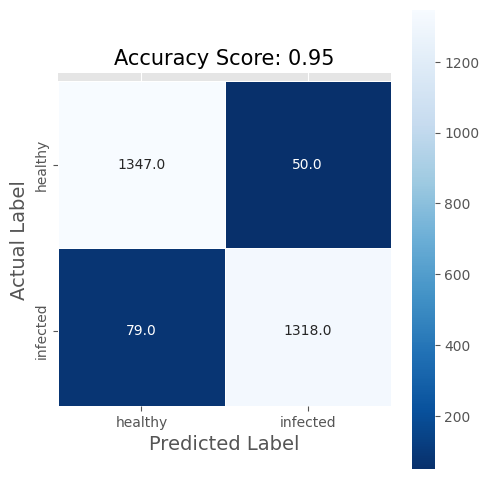

In [37]:
# Load the saved model
model_03.load_weights('model_weights/vgg_unfrozen.weights.h5')
# Evaluate the model on the hold out validation and test datasets

vgg_val_eval_03 = model_03.evaluate(valid_generator)
vgg_test_eval_03 = model_03.evaluate(test_generator)

print('Validation loss     :{0:.2f}'.format(vgg_val_eval_03[0]))
print('Validation accuracy :{0:.2f}'.format(vgg_val_eval_03[1]))
print('Test loss           :{0:.2f}'.format(vgg_test_eval_03[0]))
print('Test accuracy       :{0:.2f}'.format(vgg_test_eval_03[1]))


filenames = test_generator.filenames
nb_samples = len(filenames)
vgg_predictions_03 = model_03.predict(test_generator,
                                                steps = nb_samples,
                                                verbose=1)
vgg_pred_labels_03 = np.argmax(vgg_predictions_03, axis=1)


# Classification Report
print(classification_report(test_generator.classes, vgg_pred_labels_03, 
                            target_names=['healthy', 'infected']))
vgg_conf_mat_03 = pd.DataFrame(confusion_matrix(test_generator.classes, vgg_pred_labels_03), 
                        index=['healthy', 'infected'], 
                        columns=['healthy', 'infected'])


fig, ax = plt.subplots(figsize=(5,5))

sns.heatmap(vgg_conf_mat_03, annot=True, fmt=".1f", linewidths=0.5, square=True, cmap='Blues_r')
ax.set_ylabel("Actual Label", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=14)
all_sample_title="Accuracy Score: {0:.2f}".format(vgg_test_eval_03[1])
ax.set_title(all_sample_title, size=15)
ax.set_ylim(len(vgg_conf_mat_03)-0.05, -0.05)
plt.tight_layout()

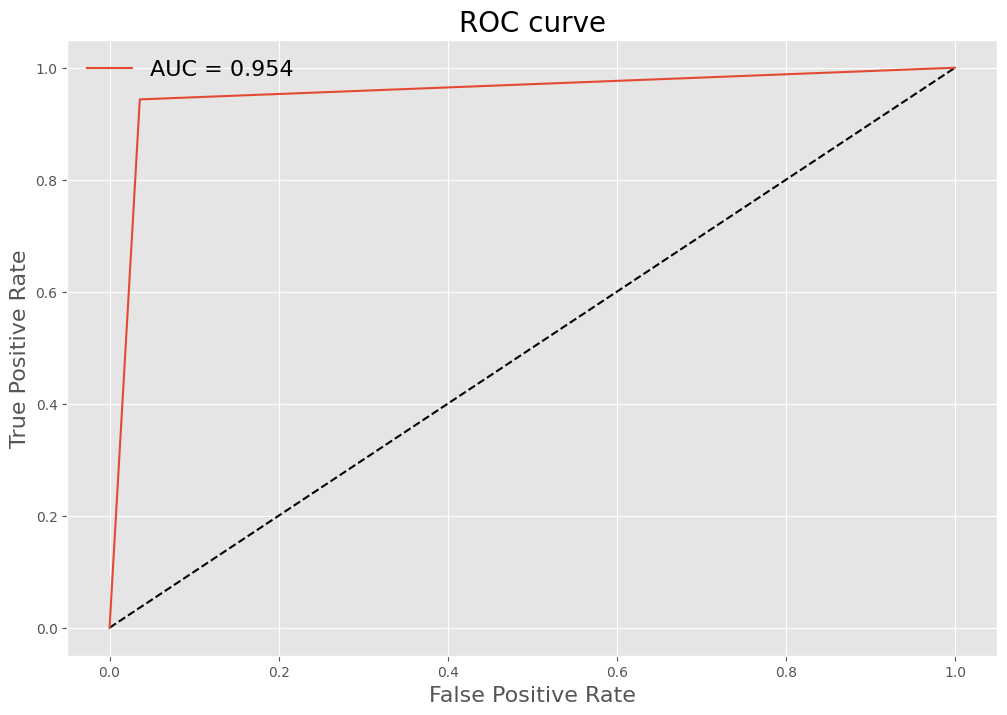

In [38]:
# AUC Curve
false_positive_rate, true_positive_rate, threshold = roc_curve(test_generator.classes, vgg_pred_labels_03)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot AUC Curve
fig, ax = plt.subplots(figsize=(12,8))
ax.plot([0,1], [0,1], 'k--')
ax.plot(false_positive_rate, true_positive_rate, label='AUC = {:.3f}'.format(area_under_curve))
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title("ROC curve", fontsize=20)
ax.legend(frameon=False, loc='best', ncol=1, fontsize=16)

# Prediction Results for 10 randomly selected images

In [39]:
test_images = [img for img in random.sample(infected_test_fpaths, 5)]
test_images.extend([img for img in random.sample(healthy_test_fpaths, 5)])
img_path = r"C:\Users\HP\OneDrive\Pictures\sample_infected.png"

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\HP\\OneDrive\\Pictures\\sample_infected.png'

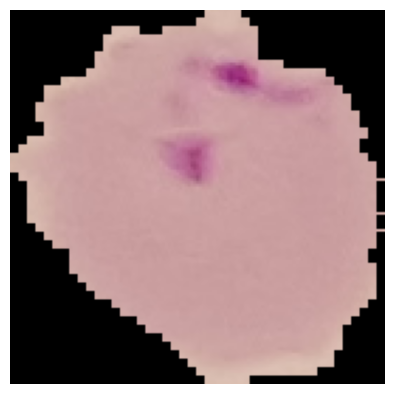

In [40]:
from tensorflow.keras.preprocessing import image
true_labels = []
predicted_labels = [] 
fig = plt.figure(figsize=(28,14))
columns=5
rows=2
for i in range(1, columns*rows +1):
    fig.add_subplot(rows, columns, i)
    true_label = os.path.basename(os.path.dirname(test_images[i-1]))
    img = mpimg.imread(test_images[i-1])
    plt.imshow(img)
    plt.axis('off')
    img_for_model = image.load_img(img_path, target_size=(128,128))
    img_for_model = image.img_to_array(img_for_model)
    img_for_model = np.expand_dims(img_for_model, axis=0)
    prediction = model_03.predict(img_for_model)
    predicted_label = np.argmax(prediction)
    plt.title(f"Predicted: {class_names[predicted_label]}\nActual: {true_label}", fontsize=16)
plt.tight_layout()
plt.show()

# Interpretable the classifier with LIME for Image Classification

In [41]:
!pip install lime


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
%load_ext autoreload
%autoreload 2
import os,sys
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


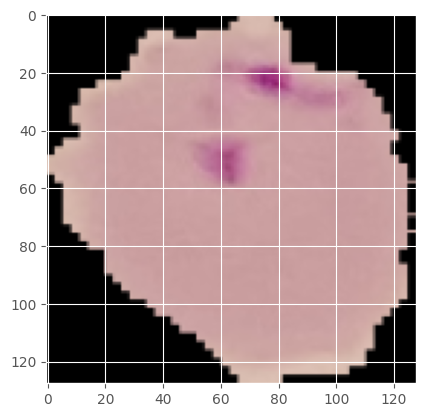

In [43]:
test_image = skimage.io.imread(test_images[0])
test_image = skimage.transform.resize(test_image, (128,128))
import matplotlib.pyplot as plt
plt.imshow(test_image)
plt.grid(True)       
plt.axis('on')       
plt.show()


# img = image.load_img(test_images[i-1], target_size=(128,128))
# img = image.img_to_array(img)
# img = np.expand_dims(img, axis = 0)
# prediction = model_03.predict(img)
# prediction

In [44]:
explainer = lime_image.LimeImageExplainer()

In [45]:
%%time
# Hide color is the color for a superpixel turned OFF. Alternatively, if it is NONE, the superpixel will be replaced by the average of its pixels
explanation = explainer.explain_instance(test_image, model_03.predict, top_labels=1, hide_color=0)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  1%|          | 10/1000 [00:02<03:29,  4.73it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


  2%|▏         | 20/1000 [00:03<02:17,  7.11it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step


 99%|█████████▉| 990/1000 [01:28<00:00, 11.81it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step


100%|██████████| 1000/1000 [01:29<00:00, 11.18it/s]

CPU times: total: 8min 21s
Wall time: 1min 29s


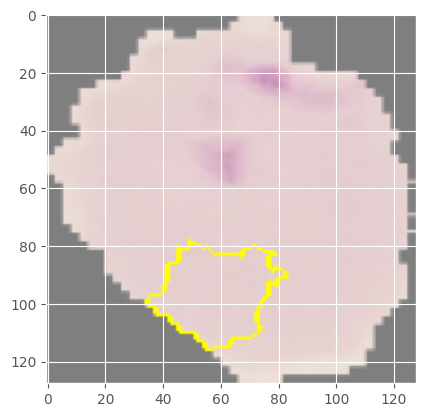

In [46]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=30, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

**Refrences:**
    1. Deep Learning with Python: François Chollet
    
    2. Malaria Detection - Deep Learning Healthcare Case-Study https://github.com/dipanjanS/data_science_for_all/blob/master/os_malaria_detection/Malaria%20Detection%20-%20Deep%20Learning%20Healthcare%20Case-Study.ipynb
    
    3. LIME Tutorial https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20Image%20Classification%20Keras.ipynb
     